/tmp/ipykernel_300/993429197.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]



Weights and capital allocation for each ticker:
 - AGG   : 0.305 -> 3,051.29
 - EEM   : 0.008 -> 76.57
 - GLD   : 0.079 -> 785.51
 - IWM   : 0.042 -> 415.17
 - QQQ   : 0.100 -> 995.97
 - SPY   : 0.103 -> 1,027.79
 - TIP   : 0.245 -> 2,445.37
 - TLT   : 0.034 -> 336.83
 - VEA   : 0.044 -> 438.11
 - VNQ   : 0.043 -> 427.39

Expected annual portfolio return: 7.250%
Expected annual portfolio volatility: 7.100%
Sharpe ratio: 0.32


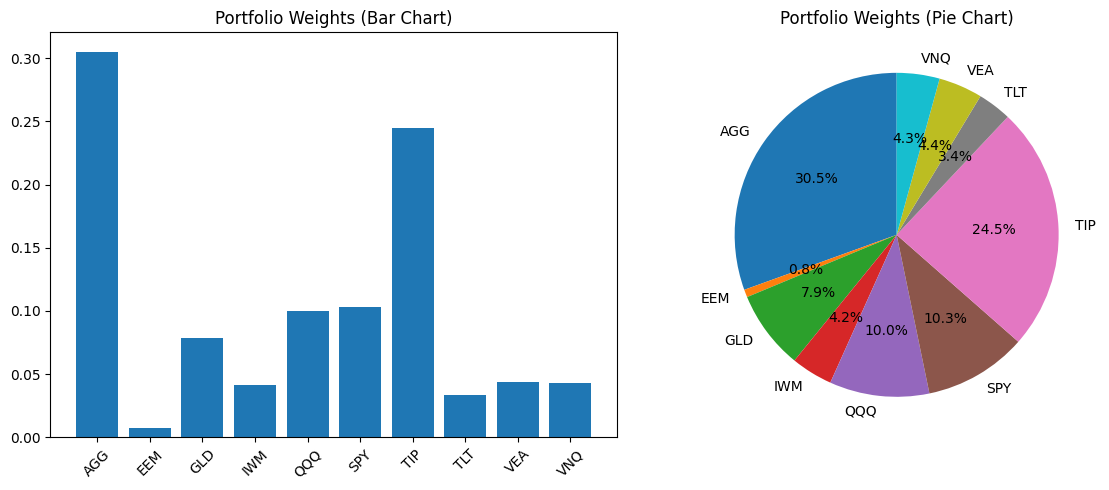

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USER INPUTS:
tickers = ["SPY", "QQQ", "IWM", "VEA", "EEM", "AGG", "TLT", "GLD", "VNQ", "TIP"]        # Choose your tickers.
start_date = "2010-01-01"           # Choose start date for data collection.
end_date = None                     # Choose end date for data collection. Write "None" if you want the data to be collected until present day.
investable_capital = 10_000         # Choose how much capital to allocate (currency is irrelevant).
risk_tolerance = 5                  # Specify rsik tolerance on a scale of 1 (conservative) to 10 (aggressive).
risk_free_rate = 0.05               # Specify annual risk-free rate.

# Download data, calculate daily returns and annualsie returns and volatility.
data = yf.download(tickers, start=start_date, end=end_date, progress=False)["Close"]
data = data.dropna()
daily_returns = data.pct_change().dropna()
trading_days = 252
annual_mean = daily_returns.mean() * trading_days
annual_volatility = daily_returns.std() * np.sqrt(trading_days)

# Define the signals: inverse volatility and return-per-volatility.

# inverse volatility: this gives more weight to less volatile assets.
inverse_volatility = 1 / annual_volatility

# return-per-volatility: this gives more weight to assets that historically delivered more return per unit of risk.
return_volatility = annual_mean / annual_volatility

# Normalise the signals
def normalize_positive(series):
    """ This function makes every value positive and scales so values sum to 1. This makes both signals interpretable together."""
    signal = series.copy().astype(float)
    signal = signal - signal.min() + 1e-9
    return signal / signal.sum()
inverse_volatility_norm = normalize_positive(inverse_volatility)
return_volatility_norm = normalize_positive(return_volatility)


# Combine signals according to risk tolerance:
risk_level = int(np.clip(risk_tolerance, 1, 10))

# Combine risk tolerance and conservative/aggressive mix and combine signals.
conservative_weight = (11 - risk_level) / 10.0
aggressive_weight = (risk_level - 1) / 9.0
combined_signal = conservative_weight * inverse_volatility_norm + aggressive_weight * return_volatility_norm

# Ensure that there are no negative numbers to ensure long-only portfolio.
combined_signal = combined_signal.clip(lower=0)
weights = combined_signal / combined_signal.sum()

# Convert weights to monetary allocation amounts.
allocation_amounts = (weights * investable_capital).round(2)

# Calculate expected portfolio return, annual covariance matrix, portfolio volatility and a simple Sharpe ratio.
portfolio_return = np.dot(weights.values, annual_mean.values)
covariance_annual = daily_returns.cov() * trading_days
portfolio_volatility = np.sqrt(weights.values @ covariance_annual.values @ weights.values.T)
sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility if portfolio_volatility > 0 else np.nan


print("\nWeights and capital allocation for each ticker:")
for ticker, weight, monetary_allocation in zip(weights.index, weights.values, allocation_amounts.values):
    print(f" - {ticker:5s} : {weight:.3f} -> {monetary_allocation:,.2f}")

print(f"\nExpected annual portfolio return: {portfolio_return:.3%}")
print(f"Expected annual portfolio volatility: {portfolio_volatility:.3%}")
print(f"Sharpe ratio: {sharpe:.2f}")

# Plot charts for the data.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart:
axes[0].bar(weights.index, weights.values)
axes[0].set_title("Portfolio Weights (Bar Chart)")
axes[0].tick_params(axis='x', rotation=45)

# Pie chart:
axes[1].pie(weights.values, labels=weights.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title("Portfolio Weights (Pie Chart)")

plt.tight_layout()
plt.show()

